In [ ]:
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", *pkgs, "-q"],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

pip("ultralytics", "kagglehub", "opencv-python-headless",
    "numpy", "matplotlib", "einops")

# ── 1. Imports ───────────────────────────────────────────────
import os, shutil, random, math, time, json
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from ultralytics import YOLO

# ── 2. Device selection (auto) ───────────────────────────────
DEVICE = "0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}  |  CUDA: {torch.cuda.is_available()}")


# ╔══════════════════════════════════════════════════════╕
# ║  SECTION A – Custom Modules (paper contributions)           ║
# ╚══════════════════════════════════════════════════════╝

# ── A1. SPDConv (Space-to-Depth Convolution) ─────
class SPD(nn.Module):
    """Lossless space-to-depth downsampling (replaces strided conv)."""
    def __init__(self, scale=2):
        super().__init__()
        self.scale = scale

    def forward(self, x):
        s = self.scale
        B, C, H, W = x.shape
        x = x.view(B, C, H // s, s, W // s, s)
        x = x.permute(0, 1, 3, 5, 2, 4).contiguous()
        return x.view(B, C * s * s, H // s, W // s)


def _autopad(k, p=None):
    return k // 2 if p is None else p


class ConvBnSilu(nn.Module):
    def __init__(self, c1, c2, k=1, s=1, p=None):
        super().__init__()
        self.conv = nn.Conv2d(c1, c2, k, s, _autopad(k, p), bias=False)
        self.bn   = nn.BatchNorm2d(c2)
        self.act  = nn.SiLU()

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class SPDConv(nn.Module):
    """Drop-in replacement for strided Conv: SPD + non-strided conv."""
    def __init__(self, c1, c2, scale=2):
        super().__init__()
        self.spd  = SPD(scale)
        self.conv = ConvBnSilu(c1 * scale * scale, c2, k=3, s=1)

    def forward(self, x):
        return self.conv(self.spd(x))


# ── A2. RCS-OSA (replaces C2f in YOLOv8) ──────────
class RepConv(nn.Module):
    """Multi-branch conv during training; single branch at inference."""
    def __init__(self, c, deploy=False):
        super().__init__()
        self.deploy = deploy
        self.c = c
        if deploy:
            self.rep = nn.Conv2d(c, c, 3, 1, 1, bias=True)
        else:
            self.conv3    = ConvBnSilu(c, c, 3, 1)
            self.conv1    = ConvBnSilu(c, c, 1, 1)
            self.identity = nn.BatchNorm2d(c)

    def forward(self, x):
        if self.deploy:
            return self.rep(x)
        return self.conv3(x) + self.conv1(x) + self.identity(x)


class RCS(nn.Module):
    """Reparameterised Convolution with Channel Shuffle."""
    def __init__(self, c, deploy=False):
        super().__init__()
        half = c // 2
        self.rep = RepConv(half, deploy=deploy)
        self.act = nn.SiLU()

    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        x2 = self.act(self.rep(x2))
        out = torch.cat([x1, x2], dim=1)
        # channel shuffle
        B, C, H, W = out.shape
        out = out.view(B, 2, C // 2, H, W).permute(0, 2, 1, 3, 4).contiguous()
        return out.view(B, C, H, W)


class SEBlock(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(c, max(1, c // r)), nn.ReLU(),
            nn.Linear(max(1, c // r), c), nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.se(x).view(x.shape[0], x.shape[1], 1, 1)


class RCS_OSA(nn.Module):
    """One-Shot Aggregation of RCS modules (replaces C2f)."""
    def __init__(self, c1, c2, n=3, use_se=True, deploy=False):
        super().__init__()
        self.proj_in  = ConvBnSilu(c1, c2, 1)
        self.blocks   = nn.ModuleList([RCS(c2, deploy) for _ in range(n)])
        n_cat = min(n, 3) + 1          # keep 3 intermediate + input
        self.proj_out = ConvBnSilu(c2 * n_cat, c2, 1)
        self.se       = SEBlock(c2) if use_se else nn.Identity()

    def forward(self, x):
        x = self.proj_in(x)
        outs = [x]
        for blk in self.blocks:
            x = blk(x)
            outs.append(x)
        kept = [outs[0]] + outs[-min(len(self.blocks), 3):]
        return self.se(self.proj_out(torch.cat(kept, dim=1)))


# ── A3. KFIoU Loss ───────────────────────────
def _obb_to_gaussian(obb):
    """obb: (...,5) = [cx,cy,w,h,angle_rad] → mu (...,2), sigma (...,2,2)"""
    cx, cy, w, h, a = [obb[..., i] for i in range(5)]
    cos_a, sin_a = torch.cos(a), torch.sin(a)
    R = torch.stack([cos_a, -sin_a, sin_a, cos_a], -1).view(*a.shape, 2, 2)
    D = torch.zeros(*a.shape, 2, 2, device=obb.device, dtype=obb.dtype)
    D[..., 0, 0] = (w / 2) ** 2
    D[..., 1, 1] = (h / 2) ** 2
    sigma = R @ D @ R.transpose(-1, -2)
    mu    = torch.stack([cx, cy], dim=-1)
    return mu, sigma


def kfiou_loss(pred, target, eps=1e-6):
    """
    pred, target: (N,5) [cx,cy,w,h,angle_rad]
    Returns scalar mean loss.
    """
    mu_p, sig_p = _obb_to_gaussian(pred)
    mu_t, sig_t = _obb_to_gaussian(target)

    sig_sum = sig_p + sig_t
    eye     = eps * torch.eye(2, device=pred.device).expand_as(sig_sum)
    sig_inv = torch.linalg.inv(sig_sum + eye)

    diff   = (mu_p - mu_t).unsqueeze(-1)
    mahal  = (diff.transpose(-1, -2) @ sig_inv @ diff).squeeze(-1).squeeze(-1)

    det_p   = torch.linalg.det(sig_p).clamp(min=eps)
    det_t   = torch.linalg.det(sig_t).clamp(min=eps)
    det_sum = torch.linalg.det(sig_sum).clamp(min=eps)

    S3  = (4 * math.pi / torch.sqrt(det_sum)) * torch.exp(-0.5 * mahal)
    S1  = math.pi * torch.sqrt(det_p)
    S2  = math.pi * torch.sqrt(det_t)
    iou = (S3 / (S1 + S2 - S3 + eps)).clamp(0.0, 1.0)
    return (1.0 - iou).mean()


class KFIoULoss(nn.Module):
    def forward(self, pred, target):
        return kfiou_loss(pred, target)


# ╔══════════════════════════════════════════════════════╕
# ║  SECTION B – Dataset Preparation                            ║
# ╚══════════════════════════════════════════════════════╝

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def _xml_to_yolo_obb_lines(xml_path, img_w, img_h):
    """Parse RolabelImg XML → list of YOLO-OBB annotation strings."""
    lines = []
    try:
        root = ET.parse(xml_path).getroot()
        size = root.find("size")
        if size is not None:
            img_w = int(size.find("width").text)
            img_h = int(size.find("height").text)

        for obj in root.findall("object"):
            rb = obj.find("robndbox")
            if rb is not None:
                cx    = float(rb.find("cx").text)
                cy    = float(rb.find("cy").text)
                w     = float(rb.find("w").text)
                h     = float(rb.find("h").text)
                angle = float(rb.find("angle").text)
                c, s  = np.cos(angle), np.sin(angle)
                hw, hh = w / 2, h / 2
                dx = np.array([-hw,  hw,  hw, -hw])
                dy = np.array([-hh, -hh,  hh,  hh])
                xs = cx + dx * c - dy * s
                ys = cy + dx * s + dy * c
                pts = np.stack([xs, ys], axis=1)
            else:
                bb = obj.find("bndbox")
                if bb is None:
                    continue
                x1 = float(bb.find("xmin").text)
                y1 = float(bb.find("ymin").text)
                x2 = float(bb.find("xmax").text)
                y2 = float(bb.find("ymax").text)
                pts = np.array([[x1,y1],[x2,y1],[x2,y2],[x1,y2]], float)

            # normalise
            pts[:, 0] /= img_w
            pts[:, 1] /= img_h
            coords = " ".join(f"{v:.6f}" for v in pts.flatten())
            lines.append(f"0 {coords}")

    except Exception as e:
        print(f"  WARNING {Path(xml_path).name}: {e}")
    return lines


def _find_pairs(dataset_root):
    """
    Locate (image_path, annotation_path_or_None) pairs.
    Handles:
      • JPEGImages/ + Annotations/   ← this Kaggle dataset
      • images/ + labels/
      • co-located files
    """
    root = Path(dataset_root)

    jpeg_dirs = [p for p in root.rglob("JPEGImages") if p.is_dir()]
    ann_dirs  = [p for p in root.rglob("Annotations") if p.is_dir()]
    if jpeg_dirs and ann_dirs:
        img_dir, ann_dir = jpeg_dirs[0], ann_dirs[0]
        print(f"  Layout: JPEGImages/ + Annotations/")
        pairs = []
        for img in sorted(img_dir.glob("*")):
            if img.suffix.lower() not in IMG_EXTS:
                continue
            xml = ann_dir / (img.stem + ".xml")
            pairs.append((img, xml if xml.exists() else None))
        return pairs

    img_dirs = [p for p in root.rglob("images") if p.is_dir()]
    lbl_dirs = [p for p in root.rglob("labels") if p.is_dir()]
    if img_dirs and lbl_dirs:
        img_dir, lbl_dir = img_dirs[0], lbl_dirs[0]
        print(f"  Layout: images/ + labels/")
        pairs = []
        for img in sorted(img_dir.rglob("*")):
            if img.suffix.lower() not in IMG_EXTS:
                continue
            rel = img.relative_to(img_dir)
            ann = lbl_dir / rel.with_suffix(".txt")
            if not ann.exists():
                ann = lbl_dir / rel.with_suffix(".xml")
            pairs.append((img, ann if ann.exists() else None))
        return pairs

    print(f"  Layout: co-located / flat")
    pairs = []
    for img in sorted(root.rglob("*")):
        if img.suffix.lower() not in IMG_EXTS:
            continue
        xml = img.with_suffix(".xml")
        txt = img.with_suffix(".txt")
        ann = xml if xml.exists() else (txt if txt.exists() else None)
        pairs.append((img, ann))
    return pairs


def build_dataset(dataset_root, out_dir, train=0.70, val=0.10, seed=42):
    """
    Convert raw dataset → YOLO-OBB folder structure.
    Returns path to dataset.yaml.
    """
    random.seed(seed)
    out = Path(out_dir)
    if out.exists():
        shutil.rmtree(out)

    pairs = _find_pairs(dataset_root)
    print(f"  Found {len(pairs)} images.")
    if not pairs:
        raise RuntimeError(f"No images found under {dataset_root}")

    random.shuffle(pairs)
    n  = len(pairs)
    nt = int(n * train)
    nv = int(n * val)
    splits = {"train": pairs[:nt], "val": pairs[nt:nt+nv], "test": pairs[nt+nv:]}

    for split in splits:
        (out / "images" / split).mkdir(parents=True, exist_ok=True)
        (out / "labels" / split).mkdir(parents=True, exist_ok=True)

    skipped = 0
    for split, lst in splits.items():
        for (img_path, ann) in lst:
            dst_img = out / "images" / split / img_path.name
            dst_lbl = out / "labels" / split / (img_path.stem + ".txt")

            try:
                shutil.copy2(img_path, dst_img)
            except Exception as e:
                print(f"  WARNING copy {img_path.name}: {e}")
                skipped += 1
                continue

            if ann is None:
                dst_lbl.write_text("")
            elif ann.suffix == ".xml":
                img = cv2.imread(str(img_path))
                h, w = img.shape[:2] if img is not None else (1000, 1000)
                lines = _xml_to_yolo_obb_lines(ann, w, h)
                dst_lbl.write_text("\n".join(lines))
            else:
                shutil.copy2(ann, dst_lbl)

    print(f"  Skipped: {skipped}")
    for s in ["train", "val", "test"]:
        ni = len(list((out / "images" / s).glob("*")))
        print(f"  {s:6s}: {ni} images")

    yaml_path = out / "dataset.yaml"
    yaml_path.write_text(
        f"path: {out.resolve()}\n"
        f"train: images/train\n"
        f"val:   images/val\n"
        f"test:  images/test\n\n"
        f"nc: 1\n"
        f"names: ['rice_seed']\n"
    )
    print(f"  Saved: {yaml_path}")
    return str(yaml_path)


# ╔══════════════════════════════════════════════════════╕
# ║  SECTION C – Model: patch YOLOv8s-OBB with custom modules   ║
# ╚══════════════════════════════════════════════════════╝

def patch_model(model):
    """
    Inject SPDConv and RCS_OSA into a loaded YOLOv8-OBB model.
    Replaces:
      • strided Conv2d (stride=2) in backbone → SPDConv
      • C2f modules                           → RCS_OSA
    """
    nn_model = model.model
    replaced_spd = replaced_rcs = 0

    # --- Replace strided convolutions with SPDConv ---
    for name, module in list(nn_model.named_modules()):
        if (isinstance(module, nn.Conv2d)
                and module.stride == (2, 2)
                and module.kernel_size == (3, 3)):
            c1, c2 = module.in_channels, module.out_channels
            new_mod = SPDConv(c1, c2, scale=2)
            parts  = name.split(".")
            parent = nn_model
            for p in parts[:-1]:
                parent = getattr(parent, p, None)
                if parent is None:
                    break
            if parent is not None:
                try:
                    setattr(parent, parts[-1], new_mod)
                    replaced_spd += 1
                except Exception:
                    pass

    # --- Replace C2f modules with RCS_OSA ---
    for name, module in list(nn_model.named_modules()):
        if "C2f" in type(module).__name__:
            try:
                c1 = module.cv1.conv.in_channels
                c2 = module.cv2.conv.out_channels
                n  = len(module.m) if hasattr(module, "m") else 3
                new_mod = RCS_OSA(c1, c2, n=n, use_se=True)
                parts  = name.split(".")
                parent = nn_model
                for p in parts[:-1]:
                    parent = getattr(parent, p, None)
                    if parent is None:
                        break
                if parent is not None:
                    setattr(parent, parts[-1], new_mod)
                    replaced_rcs += 1
            except Exception:
                pass

    print(f"  Patched: {replaced_spd} SPDConv, {replaced_rcs} RCS-OSA")
    return model


# ╔══════════════════════════════════════════════════════╕
# ║  SECTION D – Training                                       ║
# ╚══════════════════════════════════════════════════════╝

def train_model(yaml_path, epochs=300, imgsz=640, batch=8, device=DEVICE):
    model = YOLO("yolov8s-obb.pt")
    model = patch_model(model)

    print(f"\nTraining: epochs={epochs}, imgsz={imgsz}, "
          f"batch={batch}, device={device}")

    model.train(
        data      = yaml_path,
        epochs    = epochs,
        imgsz     = imgsz,
        batch     = batch,
        device    = device,
        task       = "obb",
        project   = "runs/yolorot2",
        name      = "train",
        patience  = 50,
        save      = True,
        plots     = True,
        amp       = (device != "cpu"),
        pretrained= False, # Explicitly set to False after patching the model
        # augmentation
        hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
        flipud=0.5,  fliplr=0.5, mosaic=1.0,
    )
    return model


# ╔══════════════════════════════════════════════════════╕
# ║  SECTION E – Evaluation                                     ║
# ╚══════════════════════════════════════════════════════╝

def evaluate(weights, yaml_path, imgsz=640, device=DEVICE, split="test"):
    model   = YOLO(weights)
    metrics = model.val(data=yaml_path, imgsz=imgsz,
                        device=device, split=split, verbose=True)
    print(f"\nmAP50-95 : {metrics.box.map:.4f}")
    print(f"mAP50    : {metrics.box.map50:.4f}")
    print(f"Precision: {metrics.box.mp:.4f}")
    print(f"Recall   : {metrics.box.mr:.4f}")
    return metrics


# ╔══════════════════════════════════════════════════════╕
# ║  SECTION F – Seed measurement (pixel → mm)                  ║
# ╚══════════════════════════════════════════════════════╝

def _pixels_per_mm(img):
    """Detect A4 paper in image and return px/mm ratio, or None."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, th = cv2.threshold(
        cv2.GaussianBlur(gray, (5, 5), 0), 200, 255, cv2.THRESH_BINARY
    )
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    largest = max(cnts, key=cv2.contourArea)
    approx  = cv2.approxPolyDP(largest, 0.02 * cv2.arcLength(largest, True), True)
    if len(approx) == 4:
        # A4 perimeter = 2*(210+297) = 1014 mm
        return cv2.arcLength(approx, True) / 1014.0
    return None


def measure_seeds(image_path, model, conf=0.30):
    """
    Run inference on one image, return list of seed measurements in mm.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(image_path)

    ppm = _pixels_per_mm(img) or 1.0   # fallback: report in pixels

    results = model(str(image_path), conf=conf, verbose=False)
    seeds   = []
    for r in results:
        if r.obb is None:
            continue
        for box in r.obb:
            cx, cy, w, h, angle = box.xywhr[0].cpu().numpy()
            seeds.append({
                "length_mm": round(float(max(w, h) / ppm), 2),
                "width_mm":  round(float(min(w, h) / ppm), 2),
                "conf":      round(float(box.conf.cpu()), 3),
                "angle_deg": round(math.degrees(float(angle)), 1),
            })
    return seeds


def run_inference(weights, image_paths, conf=0.30):
    model   = YOLO(weights)
    results = {}
    for img_path in image_paths:
        t0    = time.perf_counter()
        seeds = measure_seeds(img_path, model, conf)
        ms    = (time.perf_counter() - t0) * 1000
        results[str(img_path)] = {"n_seeds": len(seeds), "ms": round(ms, 1), "seeds": seeds}
        print(f"\n{Path(img_path).name}: {len(seeds)} seeds in {ms:.1f} ms")
        if seeds:
            ls = [s["length_mm"] for s in seeds]
            ws = [s["width_mm"]  for s in seeds]
            print(f"  Length: {np.mean(ls):.2f} ± {np.std(ls):.2f} mm")
            print(f"  Width : {np.mean(ws):.2f} ± {np.std(ws):.2f} mm")

    out = Path("runs/yolorot2/measurements.json")
    out.parent.mkdir(parents=True, exist_ok=True)
    out.write_text(json.dumps(results, indent=2))
    print(f"\nMeasurements saved → {out}")
    return results


# ╔══════════════════════════════════════════════════════╕
# ║  SECTION G – Main pipeline                                  ║
# ╚══════════════════════════════════════════════════════╝

if __name__ == "__main__":
    import argparse, glob as _glob

    parser = argparse.ArgumentParser(description="YOLOrot2.0 pipeline")
    parser.add_argument("--epochs",     type=int,   default=300)
    parser.add_argument("--imgsz",      type=int,   default=640)
    parser.add_argument("--batch",      type=int,   default=8)
    parser.add_argument("--device",     default=DEVICE)
    parser.add_argument("--output",     default="yolorot2_dataset")
    parser.add_argument("--skip-train", action="store_true")
    parser.add_argument("--weights",    default=None)
    args, unknown = parser.parse_known_args()

    print("=" * 60)
    print("  YOLOrot2.0 – Rice Seed Size Measurement")
    print(f"  Device: {args.device}  |  CUDA: {torch.cuda.is_available()}")
    print("=" * 60)

    # ── Step 1: download ─────────────────────
    print("\n[1/4] Downloading dataset …")
    import kagglehub
    dataset_path = kagglehub.dataset_download("jinfengzhao/riceseedsize")
    print(f"  Path: {dataset_path}")

    # ── Step 2: prepare ────────────────────
    print("\n[2/4] Preparing dataset …")
    yaml_path = build_dataset(dataset_path, args.output)

    n_train = len(list(Path(args.output, "images", "train").glob("*")))
    if n_train == 0:
        print("ERROR: train split is empty – check dataset structure.")
        sys.exit(1)

    # ── Step 3: train ────────────────────
    best = "/content/runs/obb/runs/yolorot2/train/weights/best.pt"
    if not args.skip_train and args.weights is None:
        print("\n[3/4] Training …")
        trained_model = train_model(yaml_path, epochs=args.epochs, imgsz=args.imgsz,
                    batch=args.batch, device=args.device)
        best = os.path.join(trained_model.trainer.save_dir, 'weights', 'best.pt')
    else:
        best = args.weights or best
        print(f"\n[3/4] Skipping training – using: {best}")

    # ── Step 4: evaluate ────────────────────
    print("\n[4/4] Evaluating …")
    if Path(best).exists():
        evaluate(best, yaml_path, imgsz=args.imgsz, device=args.device)
    else:
        print(f"  Weights not found at {best}")

    # ── Step 5: measure sample images ──────────
    imgs = sorted(
        _glob.glob(f"{args.output}/images/test/*.jpg") +
        _glob.glob(f"{args.output}/images/test/*.png")
    )[:5]
    if imgs and Path(best).exists():
        print(f"\n[Bonus] Measuring {len(imgs)} sample images …")
        run_inference(best, imgs)

    print("\n✓ Done")

Using device: 0  |  CUDA: True
  YOLOrot2.0 – Rice Seed Size Measurement
  Device: 0  |  CUDA: True

[1/4] Downloading dataset …
Using Colab cache for faster access to the 'riceseedsize' dataset.
  Path: /kaggle/input/riceseedsize

[2/4] Preparing dataset …
  Layout: JPEGImages/ + Annotations/
  Found 157 images.
  Skipped: 0
  train : 109 images
  val   : 15 images
  test  : 33 images
  Saved: yolorot2_dataset/dataset.yaml

[3/4] Training …
  Patched: 7 SPDConv, 8 RCS-OSA

Training: epochs=300, imgsz=640, batch=8, device=0
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolorot2_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False

### Visualize Model Predictions

Let's visualize the model's predictions on one of the test images to see the oriented bounding boxes.

Visualizing predictions for: yolorot2_dataset/images/test/0001.jpg


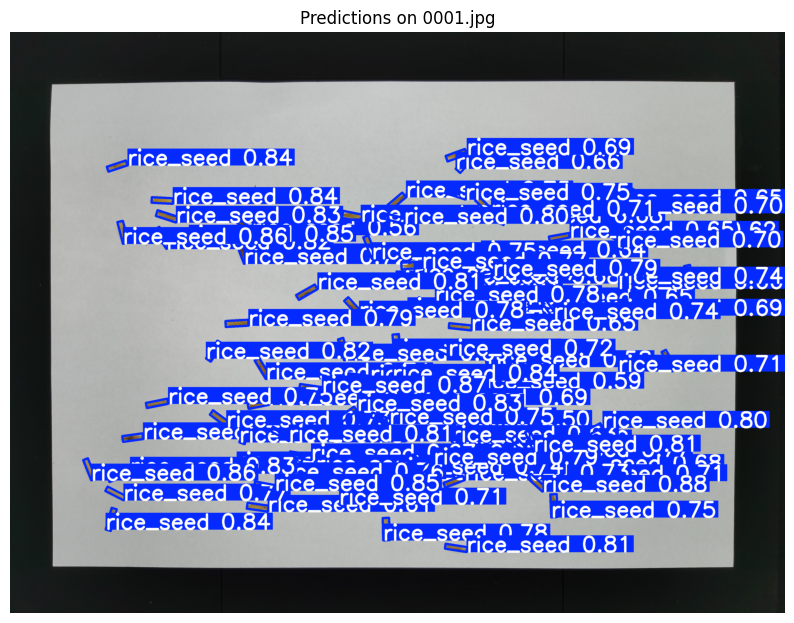

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Load the best trained model
model = YOLO(best)

# Select a sample image from the test set for visualization
# The 'imgs' variable contains paths to sample test images from the previous run.
if imgs:
    sample_image_path = imgs[0] # Take the first sample image
    print(f"Visualizing predictions for: {sample_image_path}")

    # Run inference on the image
    results = model.predict(source=sample_image_path, conf=0.3, verbose=False, task='obb')

    # Plot the results on the image
    # The plot() method returns a numpy array with drawn bounding boxes
    if results and len(results) > 0:
        annotated_img = results[0].plot() # Get the annotated image array

        # Convert BGR to RGB for matplotlib display
        annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

        # Display the image
        plt.figure(figsize=(10, 10))
        plt.imshow(annotated_img_rgb)
        plt.axis('off')
        plt.title(f'Predictions on {Path(sample_image_path).name}')
        plt.show()
    else:
        print("No detection results for the sample image.")
else:
    print("No sample images available to visualize.")